In [1]:
import pandas as pd

df = pd.read_csv('1.04.+Real-life+example.csv')

summary = {
    "head": df.head(),
    "describe": df.describe(include='all'),
    "missing_values": df.isnull().sum()
}

summary


{'head':            Brand    Price       Body  Mileage  EngineV Engine Type  \
 0            BMW   4200.0      sedan      277      2.0      Petrol   
 1  Mercedes-Benz   7900.0        van      427      2.9      Diesel   
 2  Mercedes-Benz  13300.0      sedan      358      5.0         Gas   
 3           Audi  23000.0  crossover      240      4.2      Petrol   
 4         Toyota  18300.0  crossover      120      2.0      Petrol   
 
   Registration  Year         Model  
 0          yes  1991           320  
 1          yes  1999  Sprinter 212  
 2          yes  2003         S 500  
 3          yes  2007            Q7  
 4          yes  2011         Rav 4  ,
 'describe':              Brand          Price   Body      Mileage      EngineV  \
 count         4345    4173.000000   4345  4345.000000  4195.000000   
 unique           7            NaN      6          NaN          NaN   
 top     Volkswagen            NaN  sedan          NaN          NaN   
 freq           936            NaN   16

In [2]:
df

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520
4343,Toyota,14200.0,sedan,31,NaN,Petrol,yes,2014,Corolla


In [3]:
df.describe(include = 'all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [8]:
import pandas as pd

# Load data
df = pd.read_csv('1.04.+Real-life+example.csv')

# Remove rows with missing Price or EngineV
df_clean = df.dropna(subset=['Price', 'EngineV'])

# Save cleaned file

df_clean.describe(include='all')


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000,4025
unique,7,NaN,6,NaN,NaN,4,2,NaN,306
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN,188
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627,NaN
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000,NaN
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [11]:
import pandas as pd

# Load cleaned dataset (without missing values)
df = pd.read_csv('cleaned_dataset.csv')

# Function to remove outliers using IQR method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Remove outliers for selected numerical features
numeric_cols = ['Price', 'Mileage', 'EngineV', 'Year']

df_no_outliers = df.copy()
for col in numeric_cols:
    df_no_outliers = remove_outliers_iqr(df_no_outliers, col)


df_no_outliers.describe(include='all')


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3346,3346.000000,3346,3346.00000,3346.000000,3346,3346,3346.000000,3346
unique,7,NaN,6,NaN,NaN,4,2,NaN,232
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,814,NaN,1296,NaN,NaN,1575,2989,NaN,175
mean,NaN,13096.091022,NaN,170.54214,2.229029,NaN,NaN,2006.214585,NaN
std,NaN,9142.891810,NaN,91.18809,0.653628,NaN,NaN,5.862651,NaN
min,NaN,800.000000,NaN,0.00000,0.600000,NaN,NaN,1989.000000,NaN
25%,NaN,6800.000000,NaN,107.00000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,10500.000000,NaN,165.00000,2.000000,NaN,NaN,2007.000000,NaN
75%,NaN,17500.000000,NaN,232.00000,2.500000,NaN,NaN,2011.000000,NaN



================ DATA OVERVIEW ================

           Brand    Price       Body  Mileage  EngineV Engine Type  \
0            BMW   4200.0      sedan      277      2.0      Petrol   
1  Mercedes-Benz   7900.0        van      427      2.9      Diesel   
2         Toyota  18300.0  crossover      120      2.0      Petrol   
3           Audi  14200.0      vagon      200      2.7      Diesel   
4        Renault  10799.0      vagon      193      1.5      Diesel   

  Registration  Year         Model  
0          yes  1991           320  
1          yes  1999  Sprinter 212  
2          yes  2011         Rav 4  
3          yes  2006            A6  
4          yes  2012        Megane  

Shape: (3166, 9)

Data Types:
 Brand            object
Price           float64
Body             object
Mileage           int64
EngineV         float64
Engine Type      object
Registration     object
Year              int64
Model            object
dtype: object

================ MISSING VALUES ============

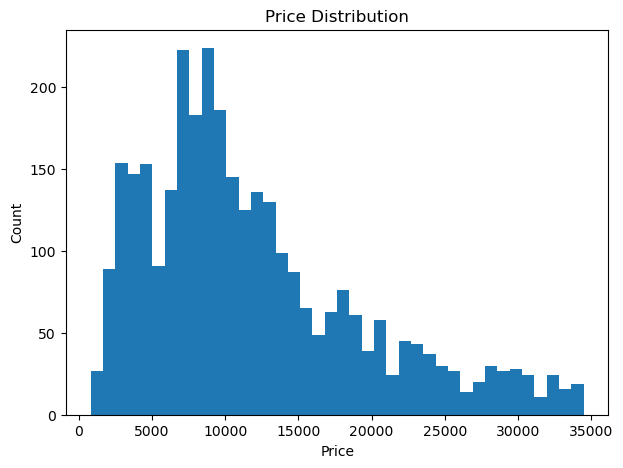

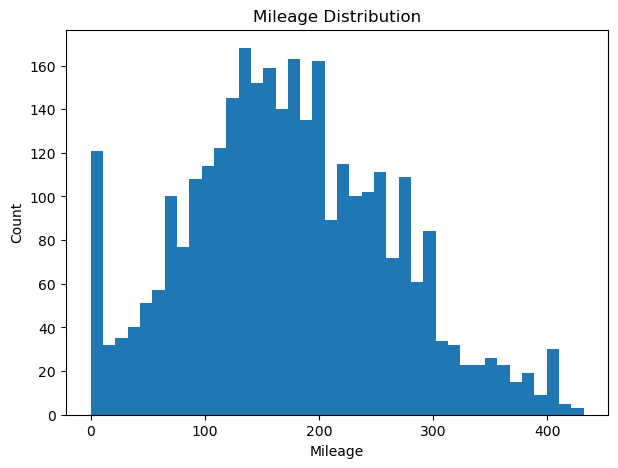

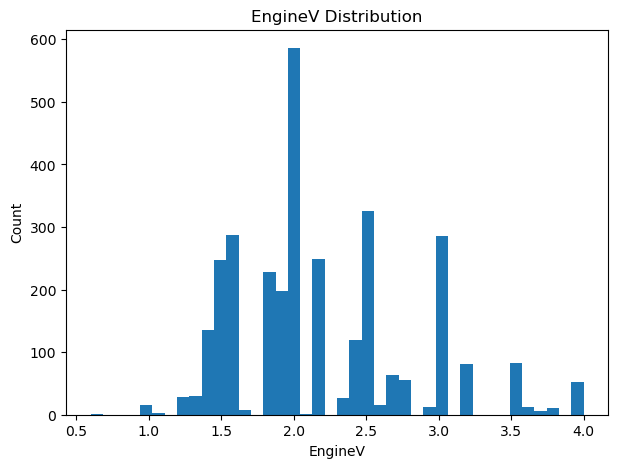

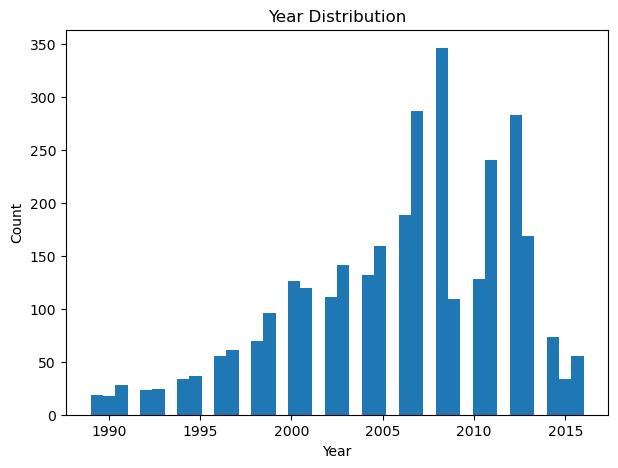

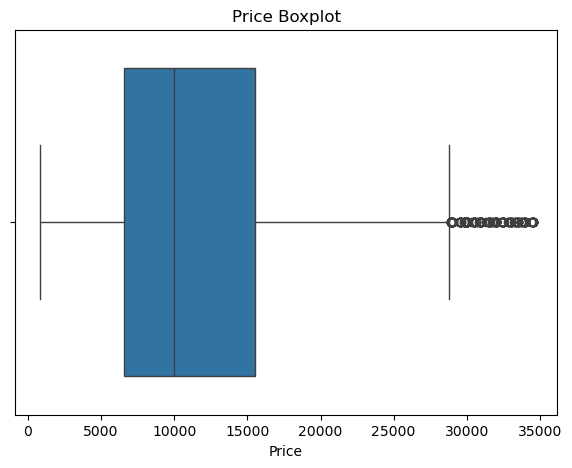

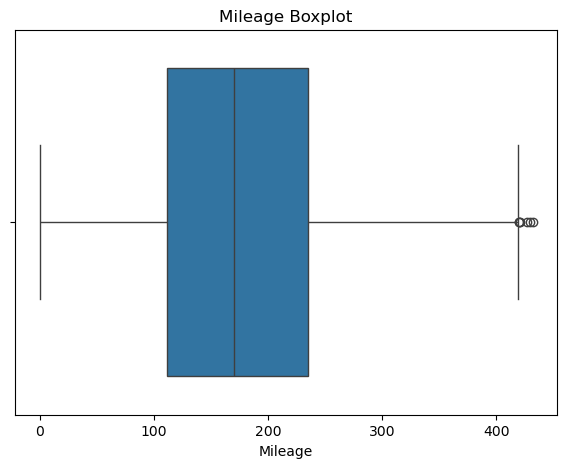

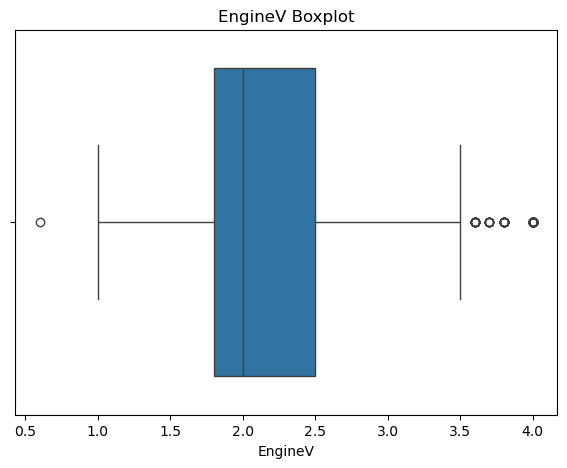

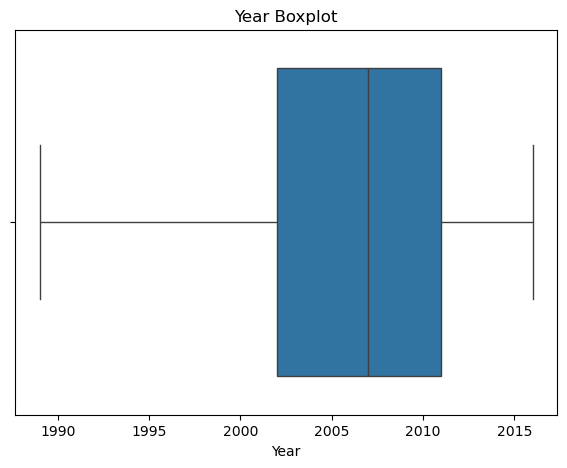

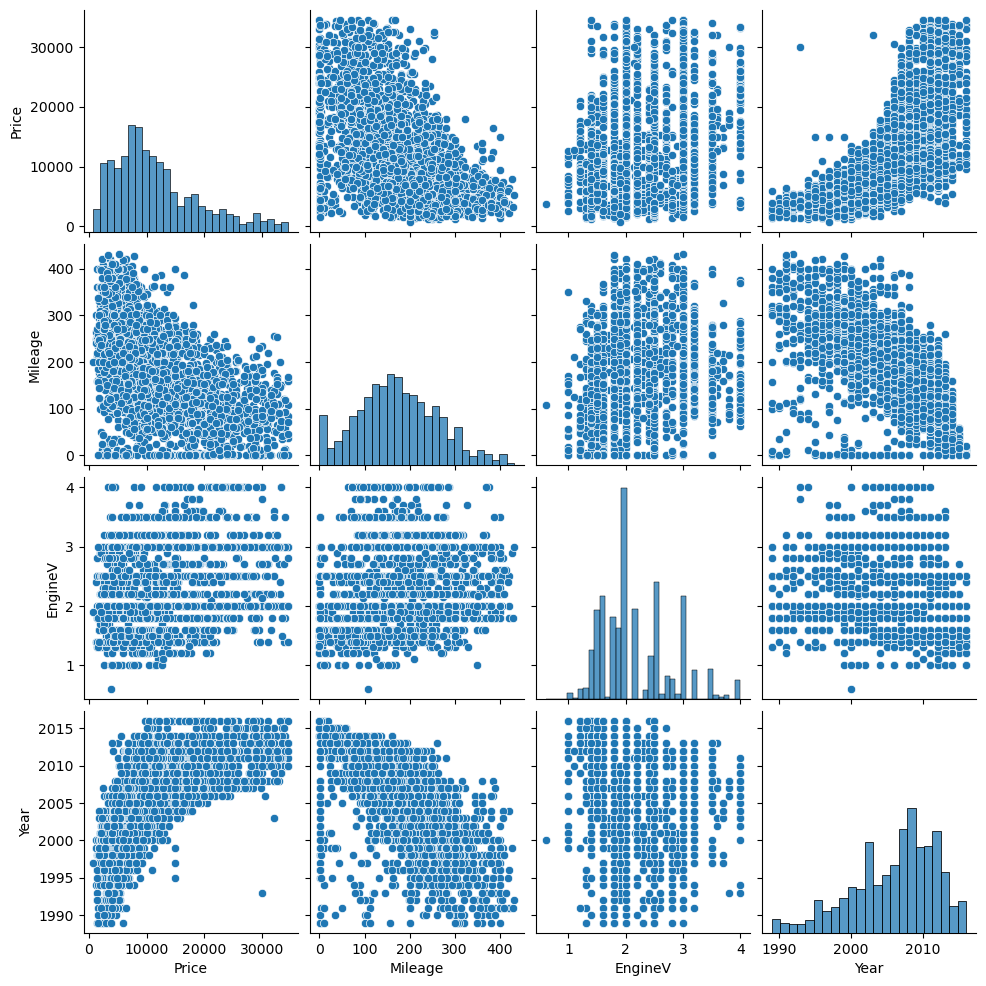

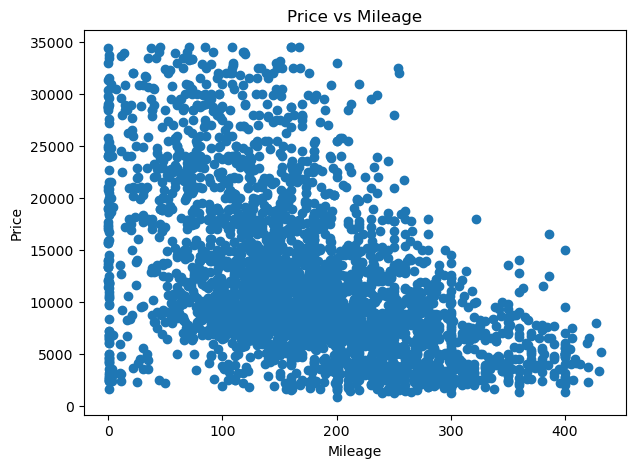

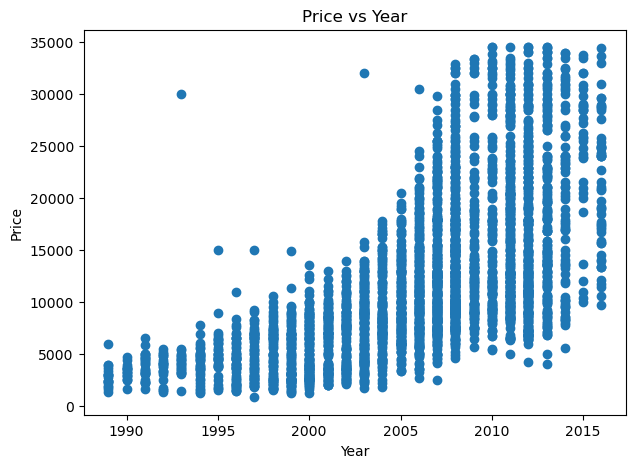

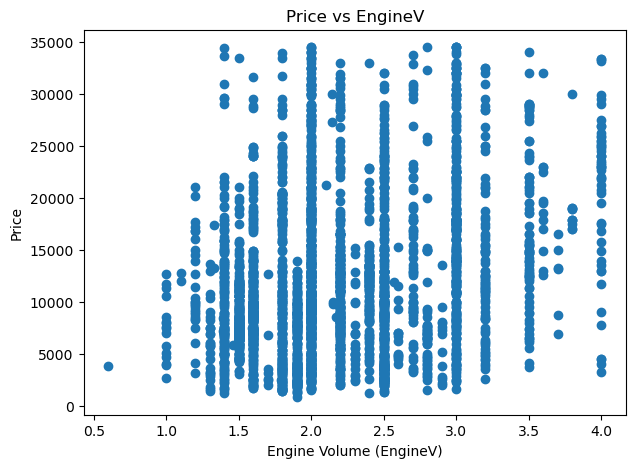

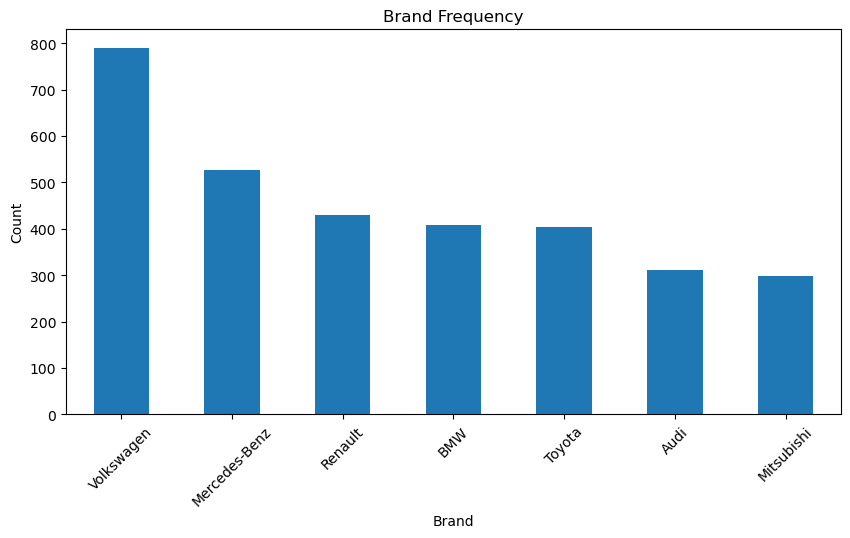

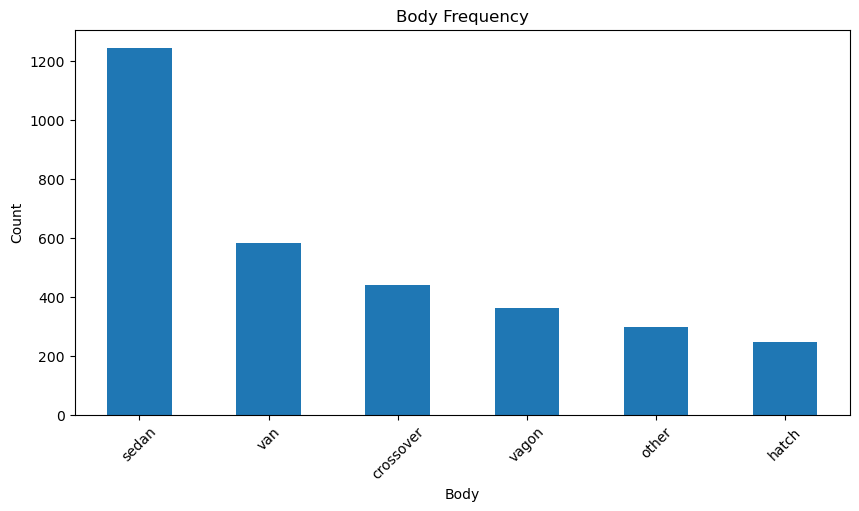

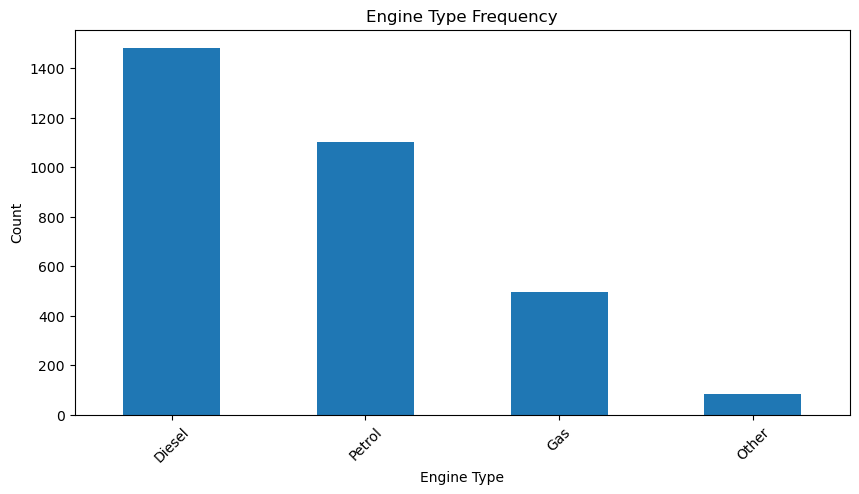

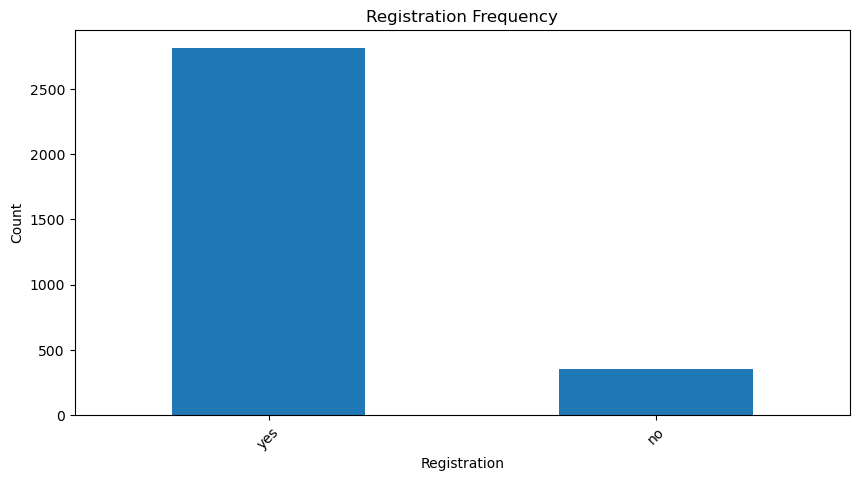

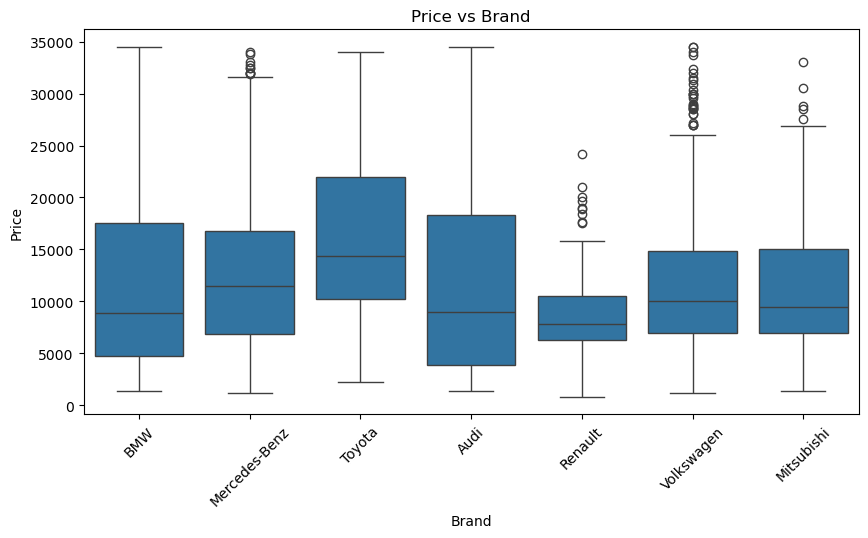

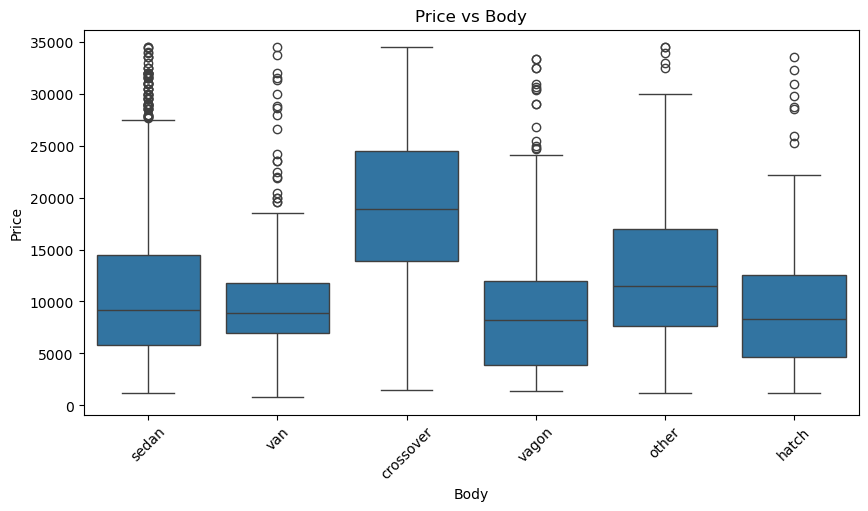

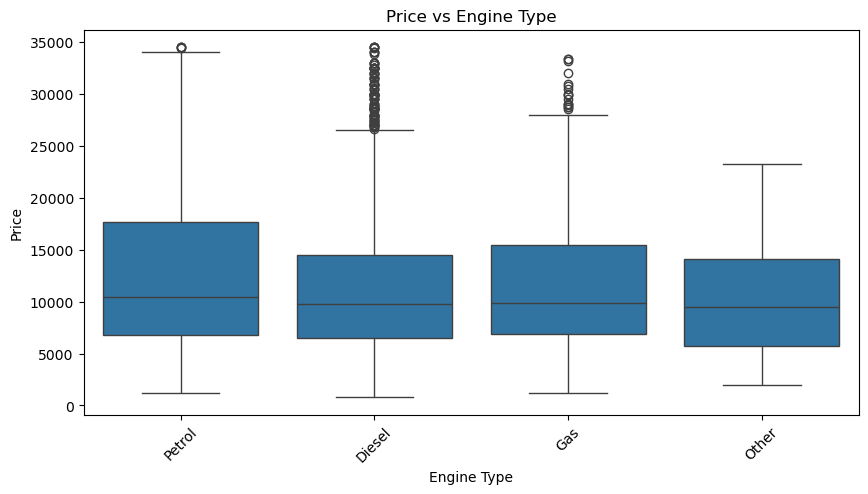

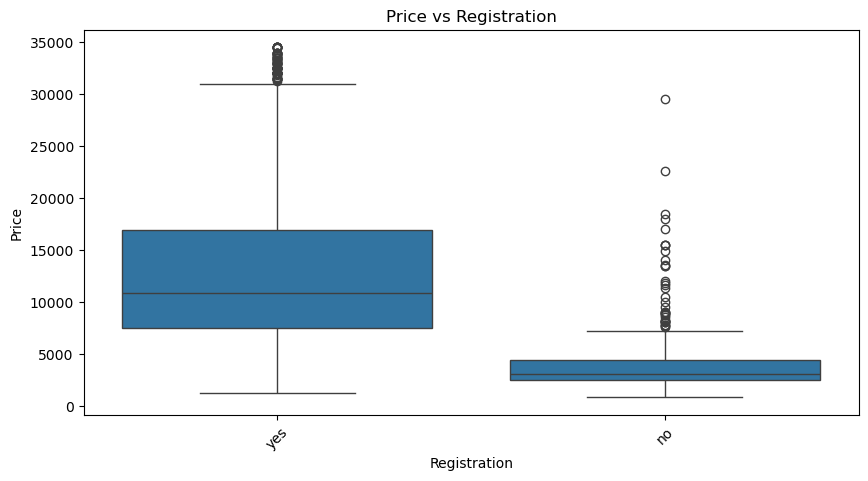

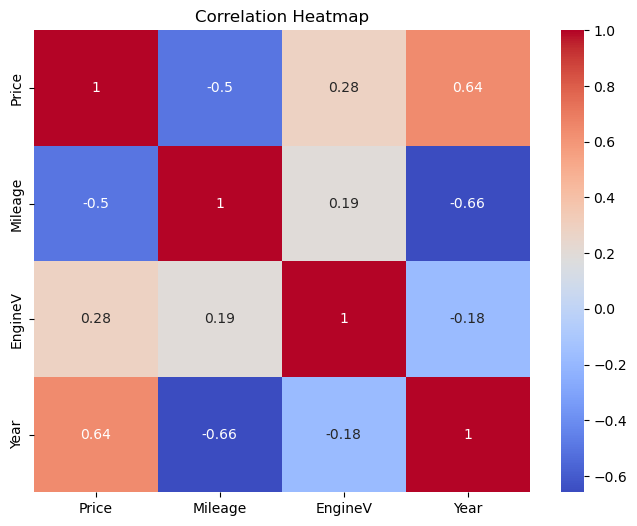



FULL EDA COMPLETED SUCCESSFULLY!
All plots saved to: /mnt/data/eda_plots



In [13]:
# ============================================
#   FULL EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --------------------------------------------
# LOAD DATA
# --------------------------------------------
df = pd.read_csv("cleaned_no_outliers_all_columns.csv")

print("\n================ DATA OVERVIEW ================\n")
print(df.head())
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)

# --------------------------------------------
# MISSING VALUES CHECK
# --------------------------------------------
print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

# --------------------------------------------
# SUMMARY STATISTICS
# --------------------------------------------
print("\n================ SUMMARY STATISTICS ================\n")
print(df.describe(include='all'))

# --------------------------------------------
# CREATE FOLDER FOR PLOTS
# --------------------------------------------
plot_dir = "/mnt/data/eda_plots"
os.makedirs(plot_dir, exist_ok=True)

# --------------------------------------------
# NUMERIC DISTRIBUTIONS
# --------------------------------------------
numeric_cols = ["Price", "Mileage", "EngineV", "Year"]

for col in numeric_cols:
    plt.figure(figsize=(7,5))
    plt.hist(df[col], bins=40)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(False)
    plt.savefig(f"{plot_dir}/{col}_distribution.png", bbox_inches='tight')
    plt.show()

# --------------------------------------------
# BOXPLOTS FOR OUTLIERS VISUALIZATION
# --------------------------------------------
for col in numeric_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.savefig(f"{plot_dir}/{col}_boxplot.png", bbox_inches='tight')
    plt.show()

# --------------------------------------------
# PAIRWISE RELATIONSHIPS
# --------------------------------------------
sns.pairplot(df[numeric_cols])
plt.savefig(f"{plot_dir}/pairplot_numeric.png", bbox_inches='tight')
plt.show()

# --------------------------------------------
# PRICE RELATIONSHIPS
# --------------------------------------------
# Price vs Mileage
plt.figure(figsize=(7,5))
plt.scatter(df["Mileage"], df["Price"])
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.savefig(f"{plot_dir}/price_vs_mileage.png", bbox_inches='tight')
plt.show()

# Price vs Year
plt.figure(figsize=(7,5))
plt.scatter(df["Year"], df["Price"])
plt.title("Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.savefig(f"{plot_dir}/price_vs_year.png", bbox_inches='tight')
plt.show()

# Price vs EngineV
plt.figure(figsize=(7,5))
plt.scatter(df["EngineV"], df["Price"])
plt.title("Price vs EngineV")
plt.xlabel("Engine Volume (EngineV)")
plt.ylabel("Price")
plt.savefig(f"{plot_dir}/price_vs_enginev.png", bbox_inches='tight')
plt.show()

# --------------------------------------------
# CATEGORICAL ANALYSIS
# --------------------------------------------
categorical_cols = ["Brand", "Body", "Engine Type", "Registration"]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} Frequency")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.savefig(f"{plot_dir}/{col}_frequency.png", bbox_inches='tight')
    plt.show()

# Boxplots Price vs Categorical
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x=col, y="Price")
    plt.title(f"Price vs {col}")
    plt.xticks(rotation=45)
    plt.savefig(f"{plot_dir}/price_vs_{col}.png", bbox_inches='tight')
    plt.show()

# --------------------------------------------
# CORRELATION HEATMAP
# --------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig(f"{plot_dir}/correlation_heatmap.png", bbox_inches='tight')
plt.show()

print("\n\n===================================")
print("FULL EDA COMPLETED SUCCESSFULLY!")
print("All plots saved to:", plot_dir)
print("===================================\n")
